In [2]:
!pip install imageio

In [3]:
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import pygmt
import scipy.spatial
import bordado as bd
from bordado._validation import longitude_continuity
import imageio
from IPython.display import Image

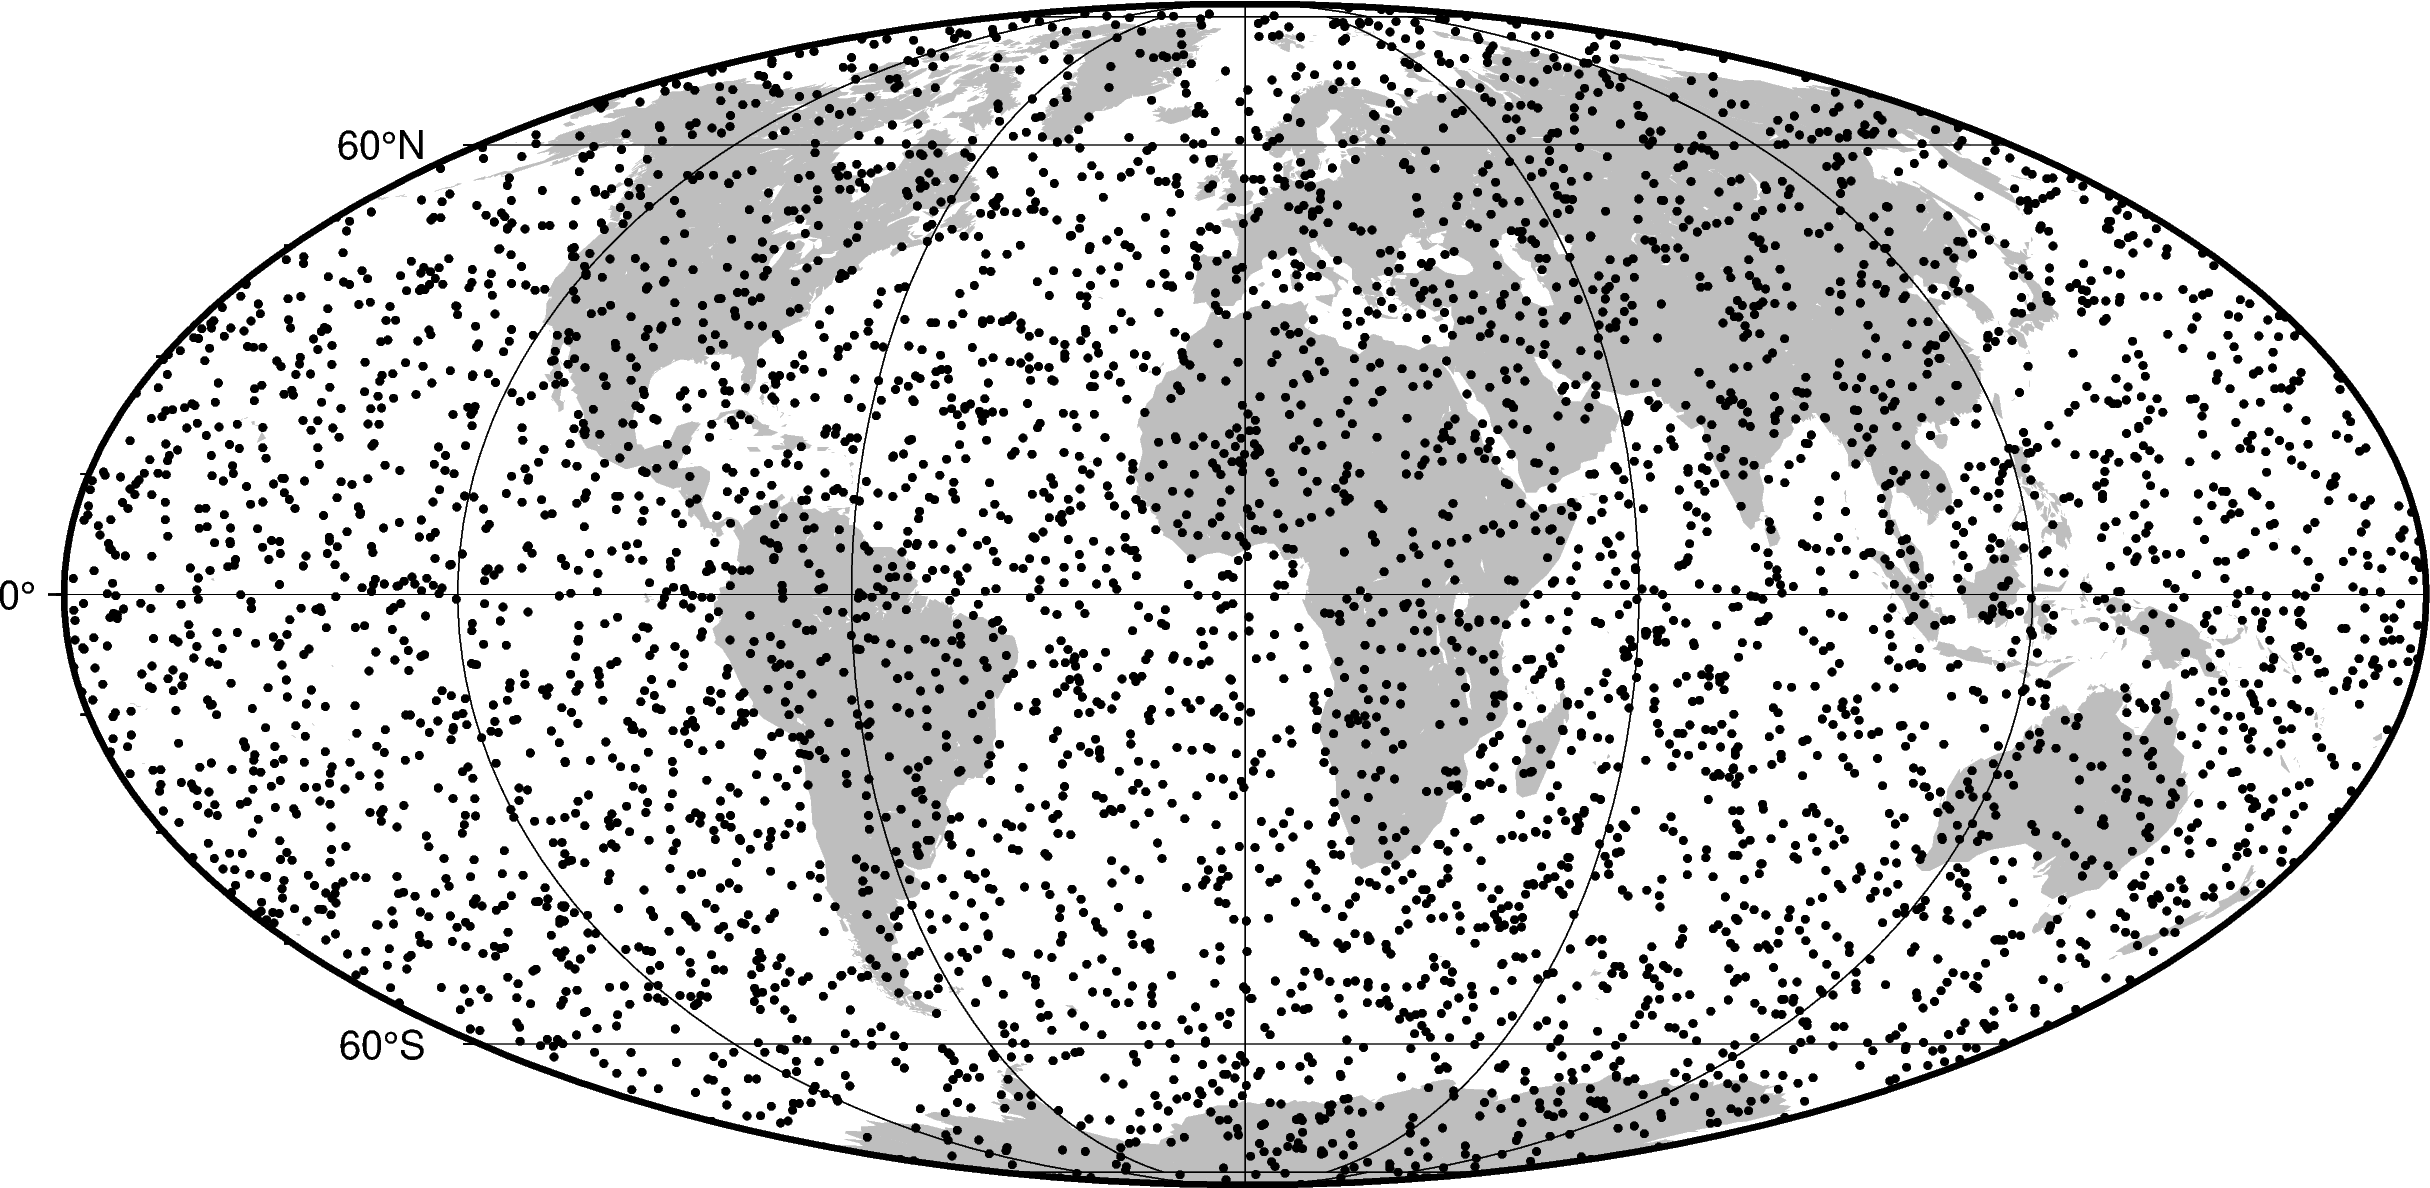

In [8]:
def random_coordinates_spherical(region, size, *, random_seed=None, non_dimensional_coords=None):
    region = longitude_continuity(region)
    random = np.random.default_rng(random_seed)
    colat_south = np.radians(90 - region[2])
    colat_north = np.radians(90 - region[3])
    xmin = (1 + np.cos(colat_north)) / 2
    xmax = (1 + np.cos(colat_south)) / 2
    coordinates = (
        random.uniform(*region[:2], size),
        90 - np.degrees(np.arccos(2 * np.random.uniform(xmin, xmax, size) - 1)),
    )
    return coordinates


region = [-180, 180, -90, 90]
coordinates = random_coordinates_spherical(region, size=5_000, random_seed=42)
fig = pygmt.Figure()
fig.coast(land="gray", region=region, projection="W0/20c", frame="afg")
fig.plot(x=coordinates[0].ravel(), y=coordinates[1].ravel(), style="c0.07c", fill="black")
fig.show()

(longitude, latitude), indices = bd.rolling_window_spherical(coordinates, region=region, window_size=65, overlap=0.5)

for i, w in enumerate(indices):
    if not all(i.size for i in w):
        continue
    fig = pygmt.Figure()
    fig.coast(land="gray", region=region, projection="W0/20c", frame="af")
    fig.plot(x=coordinates[0][w].ravel(), y=coordinates[1][w].ravel(), style="c0.07c", fill="black")
    fig.plot(x=longitude, y=latitude, style="c0.2c", fill="orange")
    fig.plot(x=longitude[i], y=latitude[i], style="c0.3c", fill="red")
    #fig.show()
    fig.savefig(f"figures/global/global-windows-{i + 1:04d}.jpg", dpi=300)

# images = [
#     imageio.v3.imread(fname)
#     for fname in sorted(Path("global").glob("*.jpg"))
# ]
# imageio.mimsave("global-windows.gif", images, duration=1000, loop=0)

# region = [0, 360, -90, -60]
# coordinates = random_coordinates_spherical(region, size=5_000, random_seed=42)
# fig = pygmt.Figure()
# fig.coast(land="gray", region=[0, 360, -90, -59], projection="S0/-90/20c", frame="af")
# fig.plot(x=coordinates[0].ravel(), y=coordinates[1].ravel(), style="c0.07c", fill="black")
# fig.show()

# (longitude, latitude), indices = bd.rolling_window_spherical(coordinates, region=region, window_size=20, overlap=0.5)

# for i, w in enumerate(indices):
#     fig = pygmt.Figure()
#     fig.coast(land="gray", region=[0, 360, -90, -59], projection="S0/-90/20c", frame="af")
#     fig.plot(x=coordinates[0][w].ravel(), y=coordinates[1][w].ravel(), style="c0.07c", fill="black")
#     fig.plot(x=longitude, y=latitude, style="c0.3c", fill="orange")
#     fig.plot(x=longitude[i], y=latitude[i], style="c0.5c", fill="red")
#     #fig.show()
#     fig.savefig(f"figures/polar/polar-windows-{i + 1:04d}.jpg", dpi=50)

# images = [
#     imageio.v3.imread(fname)
#     for fname in sorted(Path("polar").glob("*.jpg"))
# ]
# imageio.mimsave("polar-windows.gif", images, duration=500, loop=0)